# Week 2 Summary — Multimodal Baseline Model Selection

**Intern:** Amara Bibi | **Mentor:** Mateen Yaqoob | **Period:** Week 2, Day 1-5

This notebook consolidates Week 2 work: zero-shot BLIP evaluation, MLflow experiment tracking, decoding strategy comparison, and final baseline selection.

## 1. Baseline Model: Zero-Shot BLIP (Day 1)

In [3]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import pandas as pd
import os
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

df = pd.read_csv("../data/captions.txt", sep="|")
df.columns = df.columns.str.strip()
image_folder = "../data/Images"

print("✅ Baseline model: Salesforce/blip-image-captioning-base (zero-shot, greedy decoding)")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

✅ Baseline model: Salesforce/blip-image-captioning-base (zero-shot, greedy decoding)


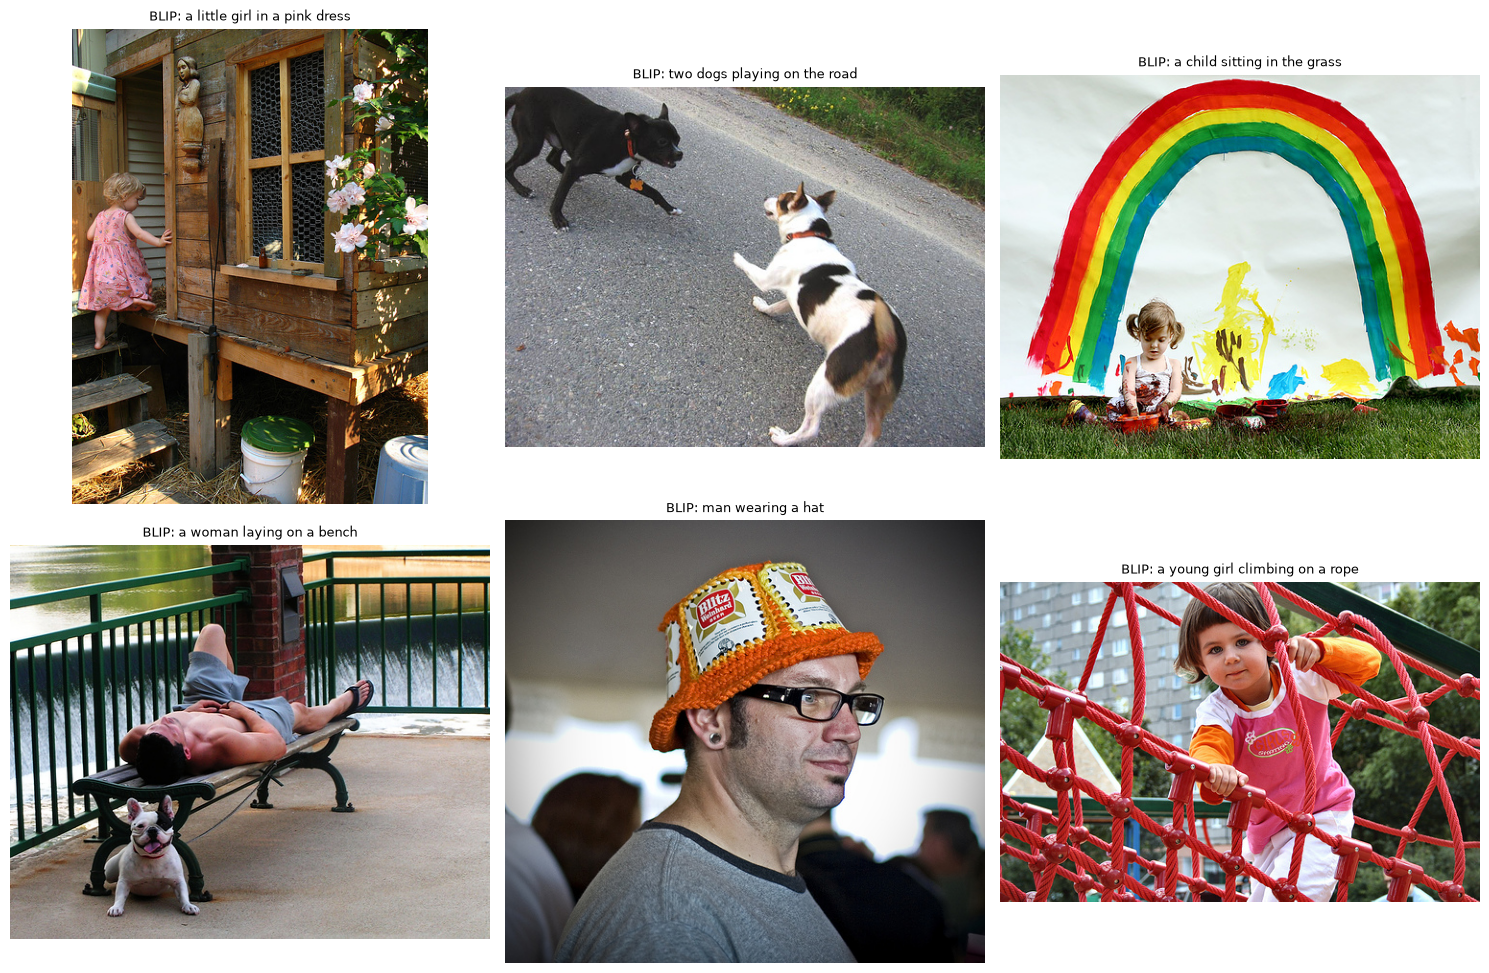

In [2]:
sample_images = df['image_name'].unique()[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(image_folder, img_name)
    raw_image = Image.open(img_path).convert("RGB")
    inputs = processor(raw_image, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=30, num_beams=1)  # greedy - final baseline choice
    caption = processor.decode(out[0], skip_special_tokens=True)
    
    axes[i].imshow(raw_image)
    axes[i].axis('off')
    axes[i].set_title(f"BLIP: {caption}", fontsize=9, wrap=True)

plt.tight_layout()
plt.savefig("../data/processed/week2_final_baseline_demo.png")
plt.show()

## 2. Evaluation Metrics Setup (Day 2)

BLEU, METEOR, and ROUGE-L were used to evaluate caption quality against Flickr8k's 5 human-written reference captions per image, on a 200-image validation subset.

In [3]:
day2_summary = pd.read_csv("../data/processed/baseline_evaluation_summary.csv")
day2_summary

,Metric,Average Score
0,BLEU,0.1968
1,METEOR,0.3950
2,ROUGE-L,0.5383


## 3. MLflow Experiment Tracking (Day 3)

All runs (baseline + fine-tuning exploration + decoding strategy comparisons) were logged to MLflow, tracking params (model, decoding strategy, beam width) and metrics (BLEU, METEOR, ROUGE-L).

## 4. Decoding Strategy Comparison (Day 4)

In [4]:
day4_comparison = pd.read_csv("../data/processed/day4_experiment_comparison.csv")
day4_comparison

,Experiment,BLEU,METEOR,ROUGE-L
0,Greedy Decoding,0.202461,0.388157,0.527728
1,Beam Search (3),0.222875,0.380398,0.508248
2,Beam Search (5),0.208757,0.387005,0.504850


## 5. Final Baseline Selection

**Chosen baseline configuration:** Zero-shot BLIP (`Salesforce/blip-image-captioning-base`) with **greedy decoding**.

**Reasoning:**
- Greedy decoding scored highest on METEOR (0.3882) and ROUGE-L (0.5277) out of the three tested configurations.
- Beam Search (3) scored slightly higher on BLEU (0.2229) but lower on the other two metrics.
- Greedy decoding is also computationally cheaper (single path per step vs. multiple beams), making it a practical choice for the current stage of the project.
- This configuration will serve as the **baseline** for comparison once fine-tuning begins in Week 3.

## 6. Week 2 Summary

- Set up zero-shot BLIP and validated it qualitatively on sample images
- Established BLEU/METEOR/ROUGE-L evaluation pipeline on a 200-image validation subset
- Set up MLflow for experiment tracking (local server)
- Explored light fine-tuning (frozen vision encoder, trainable text decoder) as a proof of concept
- Compared 3 decoding configurations (greedy, beam-3, beam-5) via MLflow
- **Final baseline: Zero-shot BLIP + greedy decoding**

**Next (Week 3):** Fine-tune BLIP's text decoder on the full/larger Flickr8k training set and re-evaluate against this baseline.